In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
lukechugh_best_alzheimer_mri_dataset_99_accuracy_path = kagglehub.dataset_download('lukechugh/best-alzheimer-mri-dataset-99-accuracy')

print('Data source import complete.')


Using Colab cache for faster access to the 'best-alzheimer-mri-dataset-99-accuracy' dataset.
Data source import complete.


In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Streaming output truncated to the last 5000 lines.
/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/train/Moderate Impairment/ModerateImpairment (2154).jpg
/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/train/Moderate Impairment/ModerateImpairment (2263).jpg
/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/train/Moderate Impairment/ModerateImpairment (2411).jpg
/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/train/Moderate Impairment/ModerateImpairment (1094).jpg
/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/train/Moderate Impairment/ModerateImpairment (1765).jpg
/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/train/Moderate Impairment/ModerateImpairment (647).jpg
/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/train/Moderate Impairment/ModerateImpairment (133).jpg
/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset

DATASET
```
combined dataset
    |__ test
        |__ No Impairment
        |__ Very Mild Impairment
        |__ Moderate Impairment
        |__ Mild Impairment
    |__ train
        |__ No Impairment
        |__ Very Mild Impairment
        |__ Moderate Impairment
        |__ Mild Impairment
```

In [ ]:
import os

In [ ]:
train_data = "/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/train"
test_data = "/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test"

def countImages(path):
    # print(os.listdir(path))
    for i in os.listdir(path):
        # print(i)
        filename = os.path.join(path, i)
        # print(filename)
        # print(os.listdir(filename))
        count = len([img for img in os.listdir(filename) if(img.lower().endswith(('.jpg', '.png', '.jpeg')))])
        print(f"{i} = {count} images")


print("Train")
countImages(train_data)
print("Test")
countImages(test_data)

Train
No Impairment = 2560 images
Very Mild Impairment = 2560 images
Moderate Impairment = 2560 images
Mild Impairment = 2560 images
Test
No Impairment = 640 images
Very Mild Impairment = 448 images
Moderate Impairment = 12 images
Mild Impairment = 179 images


## imbalanced dataset for testing

In [ ]:
mainDir = "/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset"
category = ['Mild Impairment', 'Moderate Impairment', "No Impairment", "Very Mild Impairment"]

imagepath = []
label = []

for cat in category:
    for split in ['train', 'test']:
        filepath = os.path.join(mainDir, split, cat)
        for img in os.listdir(filepath):
            img_path = os.path.join(filepath, img)
            imagepath.append(img_path)
            label.append(cat)

data = pd.DataFrame({"image_path" : imagepath, "label": label})


In [ ]:
data.sample(10)

,image_path,label
9111,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,Very Mild Impairment
1568,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,Mild Impairment
7037,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,No Impairment
9937,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,Very Mild Impairment
7175,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,No Impairment
3119,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,Moderate Impairment
5799,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,No Impairment
3303,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,Moderate Impairment
6878,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,No Impairment
7876,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,No Impairment


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
train_df, test_df = train_test_split(data, test_size=0.2, stratify=data['label'], random_state=42)
train_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

In [ ]:
train_df

,image_path,label
0,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,No Impairment
1,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,Mild Impairment
2,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,No Impairment
3,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,Mild Impairment
4,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,Moderate Impairment
...,...,...
9210,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,Moderate Impairment
9211,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,Mild Impairment
9212,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,Mild Impairment
9213,/kaggle/input/best-alzheimer-mri-dataset-99-ac...,Moderate Impairment


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
# Generates images
def show_images(gen):
    classes = list(gen.class_indices.keys())   ## extract labels -- Maps class names → numeric indices
    images, labels = next(gen)         ## extracts batch of images

    num_images = min(len(labels), 16)   ## displays only 16 images

    fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        if i < num_images:
            ax.imshow(images[i])
            label_index = np.argmax(labels[i])
            ax.set_title(classes[label_index])
            ax.axis('off')
        else:
            ax.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_training(hist):
    acc = hist.history['accuracy']
    val_acc = hist.history['val_accuracy']
    loss = hist.history['loss']
    val_loss = hist.history['val_loss']
    epochs = range(len(acc))

    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy', color='blue')
    plt.plot(epochs, val_acc, label='Validation Accuracy', color='orange')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss', color='blue')
    plt.plot(epochs, val_loss, label='Validation Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:

def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion Matrix', cmap=plt.cm.Blues):
    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], '.2f') if normalize else int(cm[i, j]),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
### DATA AUGMENTATION --> generate batches of images on the fly
## rescale=1./255: converts pixel values from [0, 255] → [0, 1] (normalization).
## validation_split=0.2: reserves 20% of training data for validation

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.08,
    shear_range=0.05,
    brightness_range=[0.9, 1.1],
    horizontal_flip=False,
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

batch_size = 16
target_size = (300, 300)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='label',
    class_mode='categorical',
    shuffle=True,
    batch_size=batch_size,
    target_size=target_size,
    subset='training'
)

val_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='label',
    class_mode='categorical',
    shuffle=False,
    batch_size=batch_size,
    target_size=target_size,
    subset='validation'
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='label',
    class_mode='categorical',
    shuffle=False,
    batch_size=batch_size,
    target_size=target_size
)

Found 7372 validated image filenames belonging to 4 classes.
Found 1843 validated image filenames belonging to 4 classes.
Found 2304 validated image filenames belonging to 4 classes.


In [ ]:
print(train_generator.samples)  # total number of images
print(train_generator.batch_size)  # batch size used
print(train_generator.class_indices)  # class names and indices


7372
16
{'Mild Impairment': 0, 'Moderate Impairment': 1, 'No Impairment': 2, 'Very Mild Impairment': 3}


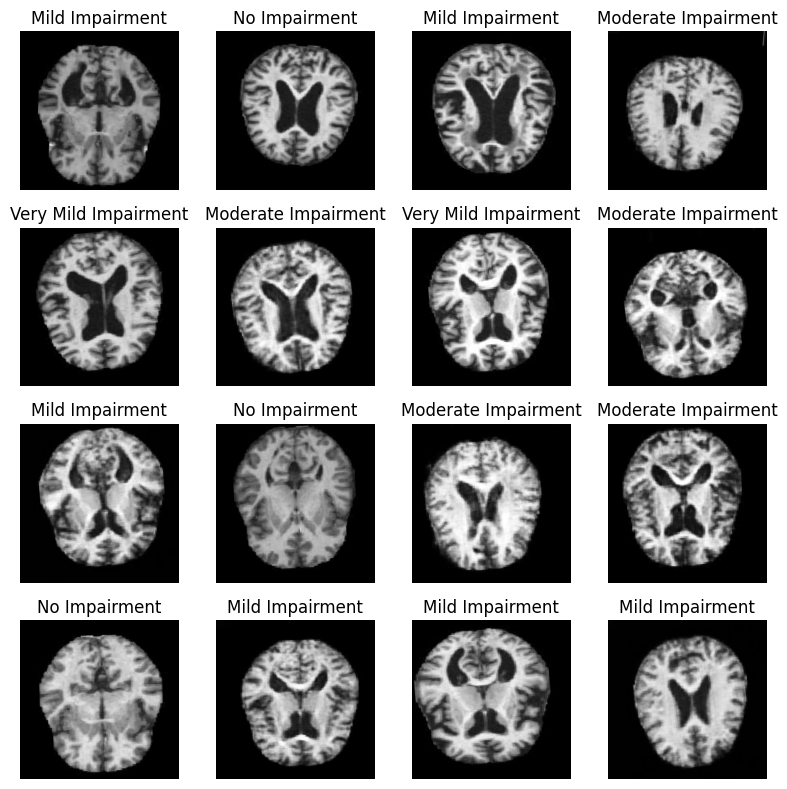

In [ ]:
show_images(train_generator)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers

In [ ]:
'''import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Model

# Image settings
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)
# Number of classes
class_count = len(list(train_generator.class_indices.keys()))

# Load base model
base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=img_shape,
    pooling= None
)

# Freeze base model if needed
base_model.trainable = True  # or False if you’re using pretrained as fixed


# Build using Functional API
x = base_model.output
x = Dense(512, activation='relu')(x)
x = Dropout(0.2)(x)
outputs = Dense(class_count, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adamax(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


SyntaxError: incomplete input (ipython-input-811665467.py, line 1)

In [ ]:
'''import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)
class_count = len(train_generator.class_indices)

base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=img_shape,
    pooling=None        # ✅ crucial for XAI!
)

base_model.trainable = False   # ✅ freeze initially

x = base_model.output
x = GlobalAveragePooling2D()(x)   # ✅ CAM-compatible
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(class_count, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

base_model = EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=(300,300,3)
)

base_model.trainable = False  # ✅ freeze initially

x = base_model.output
x = GlobalAveragePooling2D()(x)   # ✅ keeps spatial info for XAI
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

import tensorflow as tf

def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        ce = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.math.pow((1 - y_pred), gamma)
        fl = weight * ce
        return tf.reduce_mean(tf.reduce_sum(fl, axis=1))
    return loss


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.trainable = True

for layer in base_model.layers[:50]:   # freeze early layers
    layer.trainable = False


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-6),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)


In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
461/461 ━━━━━━━━━━━━━━━━━━━━ 458s 736ms/step - accuracy: 0.2738 - loss: 0.2010 - val_accuracy: 0.3039 - val_loss: 0.1899
Epoch 2/5
461/461 ━━━━━━━━━━━━━━━━━━━━ 229s 496ms/step - accuracy: 0.4153 - loss: 0.1749 - val_accuracy: 0.5665 - val_loss: 0.1415
Epoch 3/5
461/461 ━━━━━━━━━━━━━━━━━━━━ 229s 498ms/step - accuracy: 0.4961 - loss: 0.1520 - val_accuracy: 0.6218 - val_loss: 0.1165
Epoch 4/5
461/461 ━━━━━━━━━━━━━━━━━━━━ 228s 494ms/step - accuracy: 0.5633 - loss: 0.1289 - val_accuracy: 0.6668 - val_loss: 0.0977
Epoch 5/5
461/461 ━━━━━━━━━━━━━━━━━━━━ 227s 493ms/step - accuracy: 0.6008 - loss: 0.1124 - val_accuracy: 0.6810 - val_loss: 0.0830


In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=8,
    callbacks=[tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2
    )]
)


Epoch 1/8
461/461 ━━━━━━━━━━━━━━━━━━━━ 384s 628ms/step - accuracy: 0.8482 - loss: 0.0337 - val_accuracy: 0.8942 - val_loss: 0.0228 - learning_rate: 2.0000e-06
Epoch 2/8
461/461 ━━━━━━━━━━━━━━━━━━━━ 221s 480ms/step - accuracy: 0.8593 - loss: 0.0315 - val_accuracy: 0.8974 - val_loss: 0.0220 - learning_rate: 2.0000e-06
Epoch 3/8
461/461 ━━━━━━━━━━━━━━━━━━━━ 222s 482ms/step - accuracy: 0.8535 - loss: 0.0317 - val_accuracy: 0.8866 - val_loss: 0.0228 - learning_rate: 2.0000e-06
Epoch 4/8
461/461 ━━━━━━━━━━━━━━━━━━━━ 220s 477ms/step - accuracy: 0.8607 - loss: 0.0305 - val_accuracy: 0.8991 - val_loss: 0.0214 - learning_rate: 2.0000e-06
Epoch 5/8
461/461 ━━━━━━━━━━━━━━━━━━━━ 222s 481ms/step - accuracy: 0.8605 - loss: 0.0309 - val_accuracy: 0.9007 - val_loss: 0.0217 - learning_rate: 2.0000e-06
Epoch 6/8
461/461 ━━━━━━━━━━━━━━━━━━━━ 222s 480ms/step - accuracy: 0.8650 - loss: 0.0301 - val_accuracy: 0.8969 - val_loss: 0.0223 - learning_rate: 2.0000e-06
Epoch 7/8
461/461 ━━━━━━━━━━━━━━━━━━━━ 220s 47

In [ ]:
loss, acc = model.evaluate(test_generator)
print("New Test Accuracy:", acc)


144/144 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - accuracy: 0.9067 - loss: 0.0209
New Test Accuracy: 0.90625


In [ ]:
import numpy as np

tta_steps = 7
tta_preds = []

for _ in range(tta_steps):
    tta_preds.append(model.predict(test_generator, verbose=0))

final_preds = np.mean(tta_preds, axis=0)
final_labels = np.argmax(final_preds, axis=1)

tta_acc = np.mean(final_labels == test_generator.classes)
print("TTA Test Accuracy:", tta_acc)


TTA Test Accuracy: 0.90625


In [ ]:
model.save("alzheimers_effb3_90acc.h5")

In [ ]:
# Get class names in correct order
CLASS_LABELS = list(train_generator.class_indices.keys())
print(CLASS_LABELS)

['Mild Impairment', 'Moderate Impairment', 'No Impairment', 'Very Mild Impairment']


In [ ]:
y_true = test_generator.classes
y_pred = np.argmax(model.predict(test_generator, verbose=0), axis=1)

print(classification_report(y_true, y_pred, target_names=CLASS_LABELS))


                      precision    recall  f1-score   support

     Mild Impairment       0.98      0.90      0.94       548
 Moderate Impairment       1.00      1.00      1.00       514
       No Impairment       0.84      0.89      0.86       640
Very Mild Impairment       0.84      0.85      0.85       602

            accuracy                           0.91      2304
           macro avg       0.91      0.91      0.91      2304
        weighted avg       0.91      0.91      0.91      2304



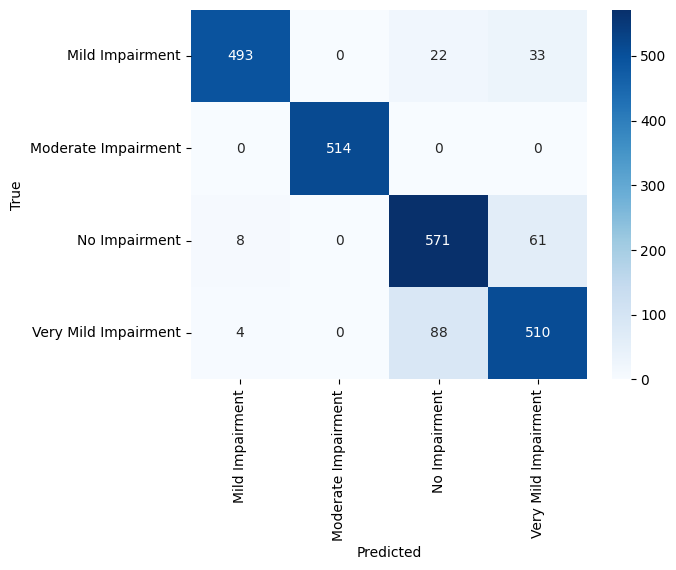

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_LABELS,
            yticklabels=CLASS_LABELS)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


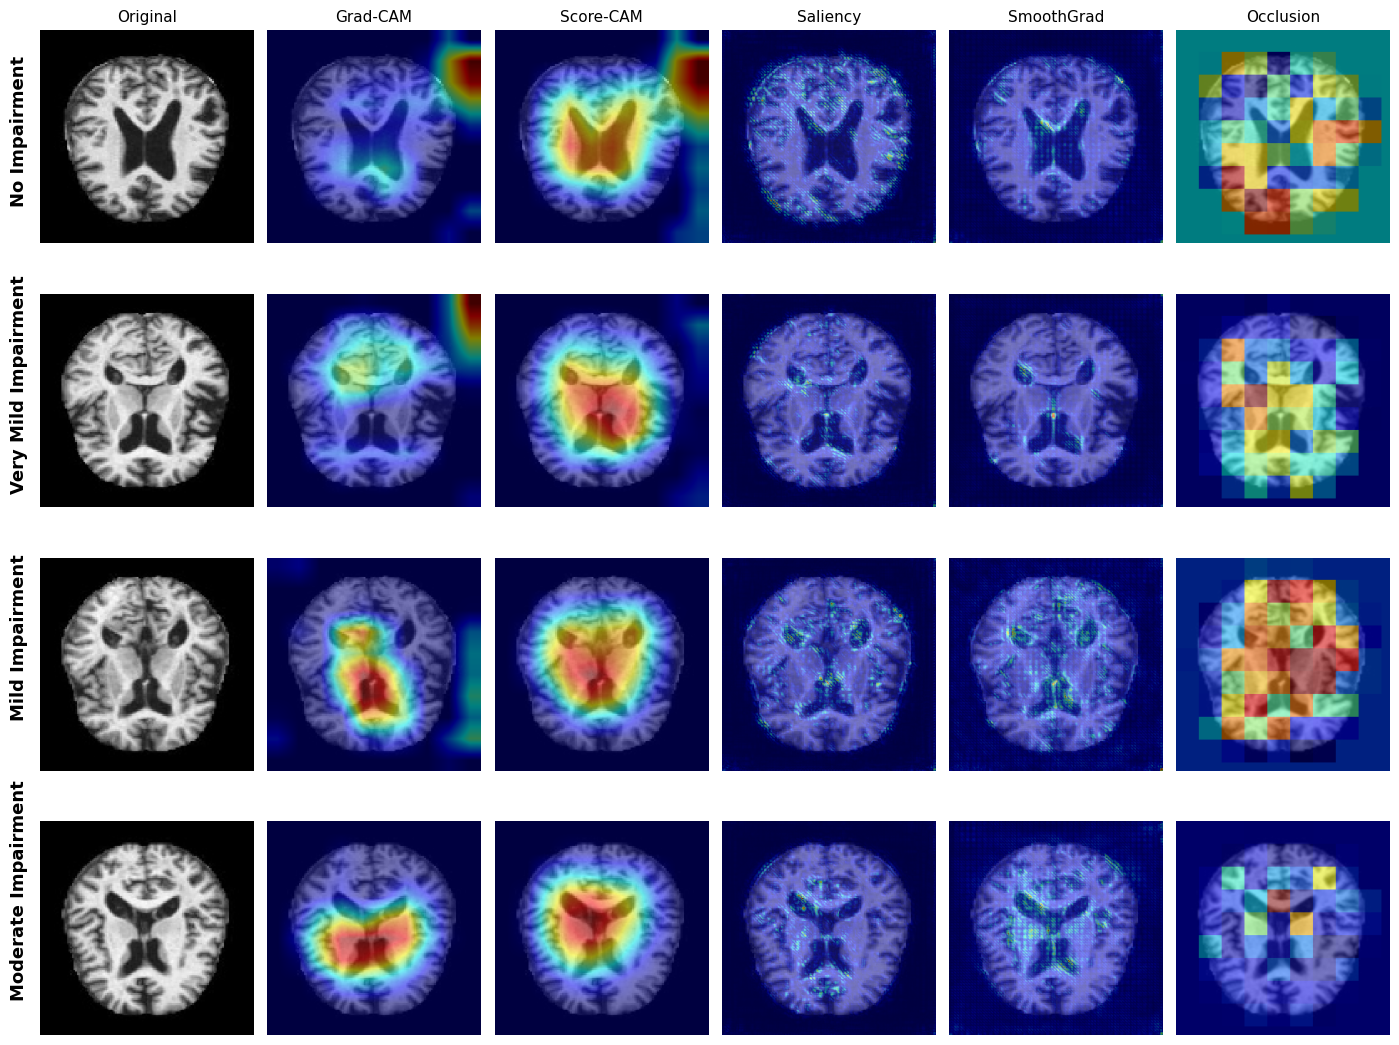

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# ========= CONFIG =========

CLASS_LABELS = [
    "No Impairment",
    "Very Mild Impairment",
    "Mild Impairment",
    "Moderate Impairment"
]

alz_paths = [
    "/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test/No Impairment/27 (89).jpg",
    "/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test/Very Mild Impairment/12 (47).jpg",
    "/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test/Mild Impairment/11 (28).jpg",
    "/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test/Moderate Impairment/19.jpg",
]

LAST_CONV_LAYER = "top_conv"   # EfficientNetB3 final conv layer
IMG_H, IMG_W = model.input_shape[1], model.input_shape[2]
IMG_SIZE = (IMG_W, IMG_H)

# Model without softmax for gradient XAI
model_no_sm = tf.keras.Model(
    inputs=model.input,
    outputs=model.layers[-2].output
)

# ========= UTILITIES =========

def load_image(img_path):
    img = load_img(img_path, target_size=IMG_SIZE)
    orig = np.array(img).astype(np.uint8)
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0) / 255.0
    return orig, x

def overlay(orig, heatmap, alpha=0.5):
    heatmap = heatmap - heatmap.min()
    if heatmap.max() > 1e-8:
        heatmap = heatmap / heatmap.max()
    h = np.uint8(255 * heatmap)
    h = cv2.applyColorMap(h, cv2.COLORMAP_JET)
    orig_bgr = cv2.cvtColor(orig, cv2.COLOR_RGB2BGR)
    blended = cv2.addWeighted(orig_bgr, 1-alpha, h, alpha, 0)
    return cv2.cvtColor(blended, cv2.COLOR_BGR2RGB)

# ========= 1. Grad-CAM =========

def gradcam(img_path):
    orig, x = load_image(img_path)
    preds = model.predict(x, verbose=0)
    idx = int(np.argmax(preds[0]))

    conv = model_no_sm.get_layer(LAST_CONV_LAYER).output
    grad_model = tf.keras.Model(inputs=model_no_sm.input, outputs=[conv, model_no_sm.output])

    with tf.GradientTape() as tape:
        conv_out, logits = grad_model(x)
        loss = logits[:, idx]

    grads = tape.gradient(loss, conv_out)[0].numpy()
    conv_out = conv_out[0].numpy()

    w = np.mean(grads, axis=(0,1))
    cam = np.sum(w * conv_out, axis=-1)
    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, IMG_SIZE)

    return overlay(orig, cam)

# ========= 2. Score-CAM =========
def scorecam(img_path, top_k=64):
    orig, x = load_image(img_path)
    preds = model.predict(x, verbose=0)
    idx = int(np.argmax(preds[0]))

    conv_layer = model.get_layer(LAST_CONV_LAYER)
    act_model = tf.keras.Model(inputs=model.input, outputs=[conv_layer.output, model.output])

    conv_out, _ = act_model(x, verbose=0)
    conv_out = conv_out[0].numpy()
    hc, wc, C = conv_out.shape

    act = conv_out.mean(axis=(0,1))
    idxs = np.argsort(act)[-top_k:]

    weights = []
    for i in idxs:
        fmap = conv_out[..., i]
        fmap = np.maximum(fmap, 0)
        if fmap.max() == 0:
            weights.append(0)
            continue

        mask = cv2.resize(fmap / fmap.max(), IMG_SIZE)
        mask = np.expand_dims(mask, axis=(0, -1))
        masked = x * mask
        score = model.predict(masked, verbose=0)[0][idx]
        weights.append(score)

    weights = np.array(weights, dtype=np.float32)

    # ✅ FIXED broadcasting
    scoremap = np.sum(conv_out[..., idxs] * weights[None, None, :], axis=-1)
    scoremap = np.maximum(scoremap, 0)
    scoremap = cv2.resize(scoremap, IMG_SIZE)

    return overlay(orig, scoremap)


# ========= 3. Saliency =========

def saliency(img_path):
    orig, x = load_image(img_path)
    x_t = tf.convert_to_tensor(x)

    with tf.GradientTape() as tape:
        tape.watch(x_t)
        logits = model_no_sm(x_t)
        idx = int(tf.argmax(logits[0]))
        loss = logits[:, idx]

    grads = tape.gradient(loss, x_t)[0].numpy()
    grads = np.max(np.abs(grads), axis=-1)

    return overlay(orig, grads)

# ========= 4. SmoothGrad =========

def smoothgrad(img_path, n=20, noise=0.15):
    orig, x = load_image(img_path)
    idx = int(np.argmax(model_no_sm.predict(x, verbose=0)[0]))

    H, W = IMG_SIZE
    accum = np.zeros((H, W))

    for _ in range(n):
        noise_img = x + noise * np.random.normal(size=x.shape)
        nt = tf.convert_to_tensor(noise_img)
        with tf.GradientTape() as tape:
            tape.watch(nt)
            logits = model_no_sm(nt)
            loss = logits[:, idx]
        g = tape.gradient(loss, nt)[0].numpy()
        g = np.max(np.abs(g), axis=-1)
        accum += g

    return overlay(orig, accum / n)

# ========= 5. Occlusion =========

def occlusion(img_path, patch=32):
    orig = cv2.imread(img_path)
    orig = cv2.resize(orig, IMG_SIZE)
    orig_rgb = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)

    base = np.expand_dims(orig_rgb/255.0, 0)
    pred = model.predict(base, verbose=0)[0]
    idx = int(np.argmax(pred))
    base_score = pred[idx]

    H, W = IMG_SIZE
    heatmap = np.zeros((H, W))

    for y in range(0, H, patch):
        for x in range(0, W, patch):
            temp = orig_rgb.copy()
            temp[y:y+patch, x:x+patch] = 0
            t = np.expand_dims(temp/255.0, 0)
            drop = base_score - model.predict(t, verbose=0)[0][idx]
            heatmap[y:y+patch, x:x+patch] = drop

    return overlay(orig_rgb, heatmap)

# ========= Build panel =========

methods = ["Original", "Grad-CAM", "Score-CAM", "Saliency", "SmoothGrad", "Occlusion"]

fig, axes = plt.subplots(4, 6, figsize=(15, 11))

for i, path in enumerate(alz_paths):
    orig, _ = load_image(path)
    row = [
        orig,
        gradcam(path),
        scorecam(path),
        saliency(path),
        smoothgrad(path),
        occlusion(path)
    ]
    for j in range(6):
        axes[i, j].imshow(row[j])
        axes[i, j].axis("off")
        if i == 0:
            axes[i, j].set_title(methods[j], fontsize=11)

for r, label in enumerate(CLASS_LABELS):
    fig.text(0.07, 0.86 - r*0.23, label,
             fontsize=13, fontweight="bold", rotation=90, va='center')

plt.tight_layout()
fig.subplots_adjust(left=0.09)
plt.show()

# save high-res for research paper
fig.savefig("alzheimers_xai_panel.png", dpi=500, bbox_inches="tight")


In [ ]:
def overlay_heatmap(img_rgb, heatmap, alpha=0.4, colormap='jet'):
    """
    img_rgb: numpy array HxW x 3 in uint8 or float [0..255] or [0..1]
    heatmap: H x W float [0..1]
    returns: overlayed image HxW x 3 uint8
    """
    import matplotlib.cm as cm
    if img_rgb.dtype != np.uint8:
        # scale to [0,255]
        img_rgb = np.uint8(np.clip(img_rgb, 0, 1) * 255) if np.max(img_rgb) <= 1.0 else np.uint8(np.clip(img_rgb, 0, 255))

    # apply colormap
    cmap = cm.get_cmap(colormap)
    heatmap_colored = cmap(heatmap)[:, :, :3]  # H,W,3 floats [0..1]
    heatmap_colored = np.uint8(heatmap_colored * 255)

    overlay = np.uint8((1.0 - alpha) * img_rgb + alpha * heatmap_colored)
    return overlay


In [ ]:
# model.compile(loss = 'categorical_crossentropy', optimizer = tf.keras.optimizers.Adam(), metrics = ['accuracy'])

early_stopping_callbacks = tf.keras.callbacks.EarlyStopping(patience = 15, restore_best_weights = True, verbose = 1)

history = model.fit(train_generator,
    validation_data=test_generator,
    epochs=30,
    steps_per_epoch = 50,
    callbacks = [early_stopping_callbacks])

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)
print("Test Accuracy:", test_accuracy)


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

def display_scorecam(model, img_path, last_conv_layer_name="conv5_block3_out", img_size=(224,224), class_labels=None):
    # Load and preprocess image
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.resnet50.preprocess_input(img_array)

    # Make prediction
    preds = model.predict(img_array)
    class_index = np.argmax(preds[0])
    class_prob = preds[0][class_index]

    # Create a model that outputs conv feature maps and predictions
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    conv_outputs, predictions = grad_model(img_array)
    conv_outputs = conv_outputs[0].numpy()

    # Generate Score-CAM
    weights = []
    for i in range(conv_outputs.shape[-1]):
        cam = conv_outputs[..., i]
        cam = np.maximum(cam, 0)
        cam = cam / (np.max(cam) + 1e-8)
        cam_resized = cv2.resize(cam, img_size)
        score = model.predict(np.expand_dims(img_array[0] * np.expand_dims(cam_resized, axis=-1), axis=0))[0][class_index]
        weights.append(score)
    weights = np.array(weights)

    scorecam = np.dot(conv_outputs, weights)
    heatmap = np.maximum(scorecam, 0)
    heatmap /= np.max(heatmap)
    heatmap = cv2.resize(heatmap, img_size)
    heatmap = np.uint8(255 * heatmap)

    # Overlay heatmap on image
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(cv2.cvtColor(np.uint8(img), cv2.COLOR_RGB2BGR), 0.6, heatmap, 0.4, 0)

    # Determine title text
    if class_labels:
        pred_label = class_labels[class_index]
        title_text = f"Pred: {pred_label} ({class_index}), Prob: {class_prob:.3f}"
    else:
        title_text = f"Pred: {class_index}, Prob: {class_prob:.3f}"

    # Display
    plt.figure(figsize=(5,5))
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title(title_text)
    plt.axis("off")
    plt.show()


In [ ]:
img_path = "/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test/Mild Impairment/28 (25).jpg"

class_labels = ['No Impairment', 'Very Mild Impairment', 'Mild Impairment', 'Moderate Impairment']

display_scorecam(model, img_path, last_conv_layer_name="conv5_block3_out", class_labels=class_labels)


In [ ]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Common utilities
# ---------------------------------------------------

def load_image_resnet(img_path, img_size=(224, 224)):
    """Load image for ResNet50: returns (orig_rgb, preprocessed_for_model)."""
    # PIL RGB for model & orig
    pil_img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
    orig_rgb = np.array(pil_img).astype(np.uint8)               # (H,W,3) 0–255

    x = tf.keras.preprocessing.image.img_to_array(pil_img)
    x = np.expand_dims(x, axis=0)
    x_pp = tf.keras.applications.resnet50.preprocess_input(x)   # model input

    return orig_rgb, x_pp


'''def overlay_heatmap_on_orig(orig_rgb, heatmap_2d, alpha=0.4):

    orig_rgb: (H,W,3) uint8 0–255, RGB
    heatmap_2d: (H,W) float or uint8
    returns RGB overlay suitable for plt.imshow
    '''
def overlay_heatmap_on_orig(orig_rgb, heatmap_2d, alpha=0.75):
    heatmap = heatmap_2d.astype(np.float32)

    heat_uint8 = np.uint8(255 * heatmap)
    heat_color = cv2.applyColorMap(heat_uint8, cv2.COLORMAP_HOT)

    orig_bgr = cv2.cvtColor(orig_rgb, cv2.COLOR_RGB2BGR)

    # ✅ stronger heatmap blending
    overlay_bgr = cv2.addWeighted(orig_bgr, 0.25, heat_color, 0.75, 0)

    return cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB)

def boost_heatmap(h):
    # 1) min-max normalize
    h = (h - h.min()) / (h.max() - h.min() + 1e-8)

    # 2) suppress low activations, keep only meaningful areas
    h = np.clip((h - 0.4) / 0.6, 0, 1)

    # 3) amplify remaining activations (gamma correction)
    h = h ** 0.3     # lower = hotter (try 0.2 or 0.1 if still blue)

    return h



# ---------------------------------------------------
# 1. Grad-CAM++
# ---------------------------------------------------

def display_gradcam_pp(model, img_path, last_conv_layer_name="conv5_block3_out",
                       img_size=(224,224), class_labels=None, return_image=False):
    orig_rgb, x_pp = load_image_resnet(img_path, img_size)

    preds = model.predict(x_pp, verbose=0)
    class_index = int(np.argmax(preds[0]))
    class_prob = float(preds[0][class_index])

    conv_layer = model.get_layer(last_conv_layer_name)
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[conv_layer.output, model.output]
    )

    x_tensor = tf.convert_to_tensor(x_pp, dtype=tf.float32)

    with tf.GradientTape(persistent=True) as tape1:
        with tf.GradientTape(persistent=True) as tape2:
            conv_out, preds_out = grad_model(x_tensor)
            loss = preds_out[:, class_index]

        first = tape2.gradient(loss, conv_out)
    second = tape1.gradient(first, conv_out)
    third  = tape1.gradient(second, conv_out)
    del tape1, tape2

    conv_out = conv_out[0].numpy()
    first    = first[0].numpy()
    second   = np.zeros_like(first) if second is None else second[0].numpy()
    third    = np.zeros_like(first) if third is None else third[0].numpy()

    global_sum = np.sum(conv_out, axis=(0,1))
    alpha = np.maximum(second / (2*second + third * global_sum + 1e-8), 0)
    weights = np.sum(alpha * np.maximum(first, 0), axis=(0,1))
    cam = np.maximum(np.sum(weights * conv_out, axis=-1), 0)

    if cam.max() > 0:
        cam /= (cam.max() + 1e-8)

    cam_resized = cv2.resize(cam, img_size)
    cam_resized = boost_heatmap(cam_resized)      # ✅ new
    overlay_rgb = overlay_heatmap_on_orig(orig_rgb, cam_resized)



    label = class_labels[class_index] if class_labels else class_index

    if return_image:
        return overlay_rgb

    plt.figure(figsize=(5,5))
    plt.imshow(overlay_rgb)
    plt.title(f"Grad-CAM++ | {label} ({class_prob:.3f})")
    plt.axis("off")
    plt.show()




# ---------------------------------------------------
# 2. Score-CAM (with verbose=0, top-k optional)
# ---------------------------------------------------

def display_scorecam(model, img_path, last_conv_layer_name="conv5_block3_out",
                     img_size=(224,224), class_labels=None, top_k=None, return_image=False):
    orig_rgb, x_pp = load_image_resnet(img_path, img_size)

    preds = model.predict(x_pp, verbose=0)
    class_index = int(np.argmax(preds[0]))
    class_prob = float(preds[0][class_index])

    conv_layer = model.get_layer(last_conv_layer_name)
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[conv_layer.output, model.output]
    )

    conv_out, _ = grad_model(x_pp, verbose=0)
    conv_out = conv_out[0].numpy()
    h, w, n_ch = conv_out.shape

    if top_k and top_k < n_ch:
        act_sum = conv_out.mean(axis=(0,1))
        idx = np.argsort(act_sum)[-top_k:]
    else:
        idx = np.arange(n_ch)

    weights = []
    for i in idx:
        fmap = conv_out[..., i]
        fmap = np.maximum(fmap, 0)
        if fmap.max() < 1e-8:
            weights.append(0)
            continue

        fmap = fmap / (fmap.max() + 1e-8)
        fmap_resized = cv2.resize(fmap, img_size)
        mask = np.expand_dims(fmap_resized, axis=-1)

        masked = np.expand_dims(x_pp[0] * mask, axis=0)
        score = model.predict(masked, verbose=0)[0][class_index]
        weights.append(score)

    weights = np.array(weights)

    scorecam = np.maximum(np.sum(conv_out[..., idx] * weights, axis=-1), 0)
    if scorecam.max() > 0:
        scorecam /= (scorecam.max() + 1e-8)

    heat_resized = cv2.resize(scorecam, img_size)
    heat_resized = boost_heatmap(heat_resized)   # ✅ boost contrast
    overlay_rgb = overlay_heatmap_on_orig(orig_rgb, heat_resized)


    label = class_labels[class_index] if class_labels else class_index

    if return_image:
        return overlay_rgb

    plt.figure(figsize=(5,5))
    plt.imshow(overlay_rgb)
    plt.title(f"Score-CAM | {label} ({class_prob:.3f})")
    plt.axis("off")
    plt.show()




# ---------------------------------------------------
# 3. Saliency (vanilla gradient)
# ---------------------------------------------------

def display_saliency(model, img_path, img_size=(224,224), class_labels=None, return_image=False):
    orig_rgb, x_pp = load_image_resnet(img_path, img_size)

    x_tensor = tf.convert_to_tensor(x_pp, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(x_tensor)
        preds = model(x_tensor, training=False)
        class_index = int(tf.argmax(preds[0]))
        loss = preds[:, class_index]

    grads = tape.gradient(loss, x_tensor)[0].numpy()
    grads = np.max(np.abs(grads), axis=-1)

    grads_norm = (grads - grads.min()) / (grads.max() - grads.min() + 1e-8)
    grads_norm = boost_heatmap(grads_norm)   # ✅ boost contrast
    overlay_rgb = overlay_heatmap_on_orig(orig_rgb, grads_norm)


    label = class_labels[class_index] if class_labels else class_index

    if return_image:
        return overlay_rgb

    plt.figure(figsize=(5,5))
    plt.imshow(overlay_rgb)
    plt.title(f"Saliency | {label}")
    plt.axis("off")
    plt.show()




# ---------------------------------------------------
# 4. SmoothGrad
# ---------------------------------------------------

def display_smoothgrad(model, img_path, img_size=(224,224),
                       n_samples=20, noise_std=0.15, class_labels=None, return_image=False):
    orig_rgb, x_pp = load_image_resnet(img_path, img_size)

    preds = model.predict(x_pp, verbose=0)
    class_index = int(np.argmax(preds[0]))
    label = class_labels[class_index] if class_labels else class_index

    H, W = img_size
    accum = np.zeros((H, W))

    for _ in range(n_samples):
        noise = noise_std * np.random.normal(size=x_pp.shape)
        noisy = x_pp + noise

        noisy_tensor = tf.convert_to_tensor(noisy, dtype=tf.float32)
        with tf.GradientTape() as tape:
            tape.watch(noisy_tensor)
            preds_noisy = model(noisy_tensor, training=False)
            loss = preds_noisy[:, class_index]

        grads = tape.gradient(loss, noisy_tensor)[0].numpy()
        grads = np.max(np.abs(grads), axis=-1)
        accum += grads

    smooth = accum / n_samples
    smooth_norm = (smooth - smooth.min()) / (smooth.max() - smooth.min() + 1e-8)

    smooth_norm = boost_heatmap(smooth_norm)   # ✅ boost contrast
    overlay_rgb = overlay_heatmap_on_orig(orig_rgb, smooth_norm)


    if return_image:
        return overlay_rgb

    plt.figure(figsize=(5,5))
    plt.imshow(overlay_rgb)
    plt.title(f"SmoothGrad | {label}")
    plt.axis("off")
    plt.show()



# ---------------------------------------------------
# 5. Occlusion Sensitivity
# ---------------------------------------------------

def display_occlusion(model, img_path, img_size=(224,224),
                      patch_size=32, class_labels=None, return_image=False):
    orig_bgr = cv2.imread(img_path)
    orig_bgr = cv2.resize(orig_bgr, img_size)
    orig_rgb = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)

    x = np.expand_dims(orig_rgb.astype(np.float32), axis=0)
    x_pp = tf.keras.applications.resnet50.preprocess_input(x)

    base_preds = model.predict(x_pp, verbose=0)[0]
    class_index = int(np.argmax(base_preds))
    base_score = float(base_preds[class_index])
    label = class_labels[class_index] if class_labels else class_index

    H, W = img_size
    heatmap = np.zeros((H, W))

    for y in range(0, H, patch_size):
        for x0 in range(0, W, patch_size):
            temp = orig_rgb.copy()
            temp[y:y+patch_size, x0:x0+patch_size] = 0

            t = np.expand_dims(temp.astype(np.float32), axis=0)
            t_pp = tf.keras.applications.resnet50.preprocess_input(t)
            pred = model.predict(t_pp, verbose=0)[0][class_index]

            heatmap[y:y+patch_size, x0:x0+patch_size] = base_score - pred

    heatmap = boost_heatmap(heatmap)   # ✅ boost contrast
    overlay_rgb = overlay_heatmap_on_orig(orig_rgb, heatmap)


    if return_image:
        return overlay_rgb

    plt.figure(figsize=(5,5))
    plt.imshow(overlay_rgb)
    plt.title(f"Occlusion | {label}")
    plt.axis("off")
    plt.show()




In [ ]:
display_gradcam_pp(model, img_path, class_labels=class_labels)
display_scorecam(model,   img_path, class_labels=class_labels, top_k=100)   # optional top_k
display_saliency(model,   img_path, class_labels=class_labels)
display_smoothgrad(model, img_path, class_labels=class_labels)
display_occlusion(model,  img_path, class_labels=class_labels, patch_size=32)

In [ ]:
import os, glob, random

def get_representative_images(base_dir, n_per_class=1, shuffle=True):
    class_to_images = {}

    # loop over folders (classes)
    for cls in sorted(os.listdir(base_dir)):
        cls_path = os.path.join(base_dir, cls)

        # skip non-directories
        if not os.path.isdir(cls_path):
            continue

        # collect all image extensions
        imgs = []
        for ext in ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif"]:
            imgs.extend(glob.glob(os.path.join(cls_path, ext)))

        if len(imgs) == 0:
            continue

        if shuffle:
            random.shuffle(imgs)

        # pick N images per class
        class_to_images[cls] = imgs[:n_per_class]

    return class_to_images


In [ ]:
base = "/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test"
alzheimers_imgs = get_representative_images(base_dir=base)
alzheimers_imgs

In [ ]:
img_no_impair     = "/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test/No Impairment/27 (89).jpg"
img_very_mild     = "/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test/Very Mild Impairment/1 (24).jpg"
img_mild          = "/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test/Mild Impairment/1 (15).jpg"
img_moderate      = "/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test/Moderate Impairment/17.jpg"

alzheimers_paths = [
    img_no_impair,
    img_very_mild,
    img_mild,
    img_moderate
]

In [ ]:
def get_xai_overlays_for_figure(img_path, model):
    # Original image (for first column)
    orig = cv2.imread(img_path)
    orig = cv2.resize(orig, (224, 224))
    orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)

    # Generate all overlays (each returns plt-shown image, so modify to return image)
    gpp = display_gradcam_pp(model, img_path, class_labels=class_labels, img_size=(224,224), return_image=True)
    sc  = display_scorecam(model, img_path, class_labels=class_labels, img_size=(224,224), top_k=100, return_image=True)
    sal = display_saliency(model, img_path, class_labels=class_labels, img_size=(224,224), return_image=True)
    sm  = display_smoothgrad(model, img_path, class_labels=class_labels, img_size=(224,224), return_image=True)
    occ = display_occlusion(model, img_path, class_labels=class_labels, img_size=(224,224), patch_size=32, return_image=True)

    return [orig, gpp, sc, sal, sm, occ]


In [ ]:
rows = [get_xai_overlays_for_figure(p, model) for p in alzheimers_paths]


In [ ]:
titles = ["Original", "Grad-CAM++", "Score-CAM", "Saliency", "SmoothGrad", "Occlusion"]
row_labels = ["No Impairment", "Very Mild", "Mild", "Moderate"]

fig, axes = plt.subplots(4, 6, figsize=(15, 10))

for i in range(4):
    for j in range(6):
        axes[i, j].imshow(rows[i][j])
        axes[i, j].axis("off")
        if i == 0:
            axes[i, j].set_title(titles[j], fontsize=12)

plt.tight_layout()
fig.subplots_adjust(left=0.08)

for idx, label in enumerate(row_labels):
    fig.text(0.06, 0.84 - idx * 0.23, label,
             fontsize=15, fontweight='bold', rotation=90, va='center')

plt.show()


In [ ]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

# ---------------------------------------------------
# 0. CONFIG: put your 4 Alzheimer test image paths here
# ---------------------------------------------------
alz_paths = [
    "/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test/No Impairment/27 (89).jpg",
    "/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test/Very Mild Impairment/12 (47).jpg",
    "/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test/Mild Impairment/11 (28).jpg",
    "/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test/Moderate Impairment/19.jpg",
]

alz_labels = ["No Impairment", "Very Mild", "Mild", "Moderate"]
img_size = (224, 224)

# ---------------------------------------------------
# 1. Utilities
# ---------------------------------------------------
def load_image_resnet(img_path, img_size=(224, 224)):
    """Return original RGB (0-255) and preprocessed input for ResNet50."""
    pil_img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
    orig_rgb = np.array(pil_img).astype(np.uint8)

    x = tf.keras.preprocessing.image.img_to_array(pil_img)
    x = np.expand_dims(x, axis=0)
    x_pp = tf.keras.applications.resnet50.preprocess_input(x)
    return orig_rgb, x_pp

def normalize_heatmap(h, gamma=0.4):
    """Strong normalization so heatmaps are not all blue."""
    h = np.nan_to_num(h.astype(np.float32))
    h = h - h.min()
    maxv = h.max()
    if maxv < 1e-8:
        return np.zeros_like(h, dtype=np.float32)
    h = h / maxv
    # gamma < 1 → boosts high values
    h = np.power(h, gamma)
    return np.clip(h, 0, 1)

def heatmap_to_rgb(h):
    """Convert 2D heatmap (0–1) to RGB using HOT colormap."""
    h_norm = normalize_heatmap(h)
    h_uint8 = np.uint8(h_norm * 255)
    heat = cv2.applyColorMap(h_uint8, cv2.COLORMAP_HOT)  # better for MRI
    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)
    return heat

# ---------------------------------------------------
# 2. XAI methods – EACH returns a 2D heatmap (no plotting)
# ---------------------------------------------------
def gradcam_pp_heatmap(model, img_path, last_conv="conv5_block3_out"):
    orig_rgb, x_pp = load_image_resnet(img_path, img_size)
    preds = model.predict(x_pp, verbose=0)
    class_idx = int(np.argmax(preds[0]))

    conv_layer = model.get_layer(last_conv)
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[conv_layer.output, model.output]
    )

    x_tensor = tf.convert_to_tensor(x_pp, dtype=tf.float32)
    with tf.GradientTape(persistent=True) as tape1:
        with tf.GradientTape(persistent=True) as tape2:
            conv_out, preds_out = grad_model(x_tensor)
            loss = preds_out[:, class_idx]
        first = tape2.gradient(loss, conv_out)
    second = tape1.gradient(first, conv_out)
    third  = tape1.gradient(second, conv_out)
    del tape1, tape2

    conv_out = conv_out[0].numpy()
    first = first[0].numpy()
    second = np.zeros_like(first) if second is None else second[0].numpy()
    third  = np.zeros_like(first) if third  is None else third[0].numpy()

    global_sum = np.sum(conv_out, axis=(0,1))
    alpha = second / (2*second + third * global_sum[np.newaxis, np.newaxis, :] + 1e-8)
    alpha = np.maximum(alpha, 0)
    weights = np.sum(alpha * np.maximum(first, 0), axis=(0,1))
    cam = np.sum(weights * conv_out, axis=-1)
    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, img_size)
    return cam

def scorecam_heatmap(model, img_path, last_conv="conv5_block3_out", top_k=64):
    orig_rgb, x_pp = load_image_resnet(img_path, img_size)
    preds = model.predict(x_pp, verbose=0)
    class_idx = int(np.argmax(preds[0]))

    conv_layer = model.get_layer(last_conv)
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[conv_layer.output, model.output]
    )
    conv_out, _ = grad_model(x_pp, verbose=0)  # (1,h,w,c)
    conv_out = conv_out[0].numpy()
    h, w, c = conv_out.shape

    # choose top-K most activated channels
    act_sum = conv_out.mean(axis=(0,1))
    idx = np.argsort(act_sum)[-top_k:]

    weights = []
    for i in idx:
        fmap = conv_out[..., i]
        fmap = np.maximum(fmap, 0)
        if fmap.max() < 1e-8:
            weights.append(0.0)
            continue
        fmap = fmap / (fmap.max() + 1e-8)
        fmap_resized = cv2.resize(fmap, img_size)
        mask = np.expand_dims(fmap_resized, axis=-1)  # (H,W,1)

        masked = x_pp[0] * mask
        masked = np.expand_dims(masked, axis=0)
        score = model.predict(masked, verbose=0)[0][class_idx]
        weights.append(score)

    weights = np.array(weights, dtype=np.float32)
    scorecam = np.zeros((h, w), dtype=np.float32)
    for k, i in enumerate(idx):
        scorecam += weights[k] * conv_out[..., i]
    scorecam = np.maximum(scorecam, 0)
    scorecam = cv2.resize(scorecam, img_size)
    return scorecam

def saliency_heatmap(model, img_path):
    orig_rgb, x_pp = load_image_resnet(img_path, img_size)
    x_tensor = tf.convert_to_tensor(x_pp, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(x_tensor)
        preds = model(x_tensor, training=False)
        class_idx = int(tf.argmax(preds[0]))
        loss = preds[:, class_idx]
    grads = tape.gradient(loss, x_tensor)[0].numpy()  # (H,W,3)
    grads = np.max(np.abs(grads), axis=-1)  # (H,W)
    return grads

def smoothgrad_heatmap(model, img_path, n_samples=20, noise_std=0.15):
    orig_rgb, x_pp = load_image_resnet(img_path, img_size)
    preds = model.predict(x_pp, verbose=0)
    class_idx = int(np.argmax(preds[0]))
    H, W = img_size
    accum = np.zeros((H, W), dtype=np.float32)

    for _ in range(n_samples):
        noise = noise_std * np.random.normal(size=x_pp.shape)
        noisy = x_pp + noise
        noisy_t = tf.convert_to_tensor(noisy, dtype=tf.float32)
        with tf.GradientTape() as tape:
            tape.watch(noisy_t)
            preds_noisy = model(noisy_t, training=False)
            loss = preds_noisy[:, class_idx]
        grads = tape.gradient(loss, noisy_t)[0].numpy()
        grads = np.max(np.abs(grads), axis=-1)
        accum += grads

    smooth = accum / n_samples
    return smooth

def occlusion_heatmap(model, img_path, patch=32):
    orig_bgr = cv2.imread(img_path)
    orig_bgr = cv2.resize(orig_bgr, img_size)
    orig_rgb = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)

    x = np.expand_dims(orig_rgb.astype(np.float32), axis=0)
    x_pp = tf.keras.applications.resnet50.preprocess_input(x)
    base_preds = model.predict(x_pp, verbose=0)[0]
    class_idx = int(np.argmax(base_preds))
    base_score = float(base_preds[class_idx])

    H, W = img_size
    heat = np.zeros((H, W), dtype=np.float32)
    for y in range(0, H, patch):
        for x0 in range(0, W, patch):
            temp = orig_rgb.copy()
            temp[y:y+patch, x0:x0+patch] = 0
            t = np.expand_dims(temp.astype(np.float32), axis=0)
            t_pp = tf.keras.applications.resnet50.preprocess_input(t)
            pred = model.predict(t_pp, verbose=0)[0][class_idx]
            drop = base_score - float(pred)
            heat[y:y+patch, x0:x0+patch] = drop
    return heat

# ---------------------------------------------------
# 3. Get 6 RGB images for a single Alzheimer scan
# ---------------------------------------------------
def get_xai_images_for_panel(model, img_path):
    orig_rgb, _ = load_image_resnet(img_path, img_size)

    h_gc   = gradcam_pp_heatmap(model, img_path)
    h_sc   = scorecam_heatmap(model, img_path)
    h_sal  = saliency_heatmap(model, img_path)
    h_sm   = smoothgrad_heatmap(model, img_path)
    h_occ  = occlusion_heatmap(model, img_path)

    img_gc   = heatmap_to_rgb(h_gc)
    img_sc   = heatmap_to_rgb(h_sc)
    img_sal  = heatmap_to_rgb(h_sal)
    img_sm   = heatmap_to_rgb(h_sm)
    img_occ  = heatmap_to_rgb(h_occ)

    return [
        orig_rgb,   # Original MRI
        img_gc,
        img_sc,
        img_sal,
        img_sm,
        img_occ
    ]

# ---------------------------------------------------
# 4. Build 4×6 Alzheimer panel
# ---------------------------------------------------
rows = [get_xai_images_for_panel(model, p) for p in alz_paths]

titles = ["Original", "Grad-CAM++", "Score-CAM", "Saliency", "SmoothGrad", "Occlusion"]

fig, axes = plt.subplots(4, 6, figsize=(15, 11))

for i in range(4):
    for j in range(6):
        axes[i, j].imshow(rows[i][j])
        axes[i, j].axis("off")
        if i == 0:
            axes[i, j].set_title(titles[j], fontsize=13)

plt.tight_layout()
fig.subplots_adjust(left=0.18)

for idx, lab in enumerate(alz_labels):
    fig.text(0.07, 0.86 - idx*0.23, lab,
             fontsize=15, fontweight='bold', rotation=90, va='center')

plt.show()
fig.savefig("alzheimers_xai_panel_final.png", dpi=450, bbox_inches="tight")


In [ ]:
import os, glob

def get_one_image_per_class(base_dir):
    image_dict = {}
    for cls in sorted(os.listdir(base_dir)):
        cls_path = os.path.join(base_dir, cls)
        if not os.path.isdir(cls_path):
            continue

        imgs = []
        for ext in ["*.jpg", "*.jpeg", "*.png", "*.bmp"]:
            imgs.extend(glob.glob(os.path.join(cls_path, ext)))

        if len(imgs) > 0:
            image_dict[cls] = imgs[0]   # first image (stable output)

    return image_dict


In [ ]:
def get_xai_panel_images(model, img_path, class_labels):
    return [
        cv2.cvtColor(cv2.resize(cv2.imread(img_path), (224,224)), cv2.COLOR_BGR2RGB),                                # Original
        display_gradcam_pp(model, img_path, class_labels=class_labels, img_size=(224,224), return_image=True),
        display_scorecam(model, img_path, class_labels=class_labels, img_size=(224,224), top_k=100, return_image=True),
        display_saliency(model, img_path, class_labels=class_labels, img_size=(224,224), return_image=True),
        display_smoothgrad(model, img_path, class_labels=class_labels, img_size=(224,224), return_image=True),
        display_occlusion(model, img_path, class_labels=class_labels, img_size=(224,224), patch_size=32, return_image=True)
    ]


In [ ]:
import matplotlib.pyplot as plt

def build_alzheimer_panel(model, base_dir, class_labels):
    img_dict = get_one_image_per_class(base_dir)

    rows = []
    ordered_classes = class_labels  # ensures row order matches labels

    for cls in ordered_classes:
        img_path = img_dict[cls]
        rows.append(get_xai_panel_images(model, img_path, class_labels))

    titles = ["Original", "Grad-CAM++", "Score-CAM", "Saliency", "SmoothGrad", "Occlusion"]

    fig, axes = plt.subplots(len(rows), 6, figsize=(16, 10))

    for i, row in enumerate(rows):
        for j, image in enumerate(row):
            axes[i][j].imshow(image)
            axes[i][j].axis("off")
            if i == 0:
                axes[i][j].set_title(titles[j], fontsize=12)

    plt.tight_layout()
    fig.subplots_adjust(left=0.16)

    for idx, label in enumerate(ordered_classes):
        fig.text(0.06, 0.84 - idx * 0.23, label,
                 fontsize=15, fontweight='bold', rotation=90, va='center')

    plt.show()

    fig.savefig("alzheimers_xai_panel.png", dpi=400, bbox_inches="tight")


In [ ]:
base_dir = "/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset/test"

class_labels = [
    "No Impairment",
    "Very Mild Impairment",
    "Mild Impairment",
    "Moderate Impairment"
]

build_alzheimer_panel(model, base_dir, class_labels)


In [ ]:
titles = ["Original", "Grad-CAM++", "Score-CAM", "Saliency", "SmoothGrad", "Occlusion"]
row_labels = ["No Impairment", "Very Mild", "Mild", "Moderate"]

rows = [row_no_impair, row_vmi, row_mild, row_mod]

fig, axes = plt.subplots(4, 6, figsize=(15, 10))

for i in range(4):
    for j in range(6):
        axes[i, j].imshow(rows[i][j])
        axes[i, j].axis("off")
        if i == 0:
            axes[i, j].set_title(titles[j], fontsize=11)

# tighten layout before adding row labels
plt.tight_layout()
fig.subplots_adjust(left=0.12)

# add left-side class labels
fig.text(0.03, 0.84, "No Impairment", fontsize=15, fontweight='bold', rotation=90, va='center')
fig.text(0.03, 0.61, "Very Mild Impairment", fontsize=15, fontweight='bold', rotation=90, va='center')
fig.text(0.03, 0.38, "Mild Impairment", fontsize=15, fontweight='bold', rotation=90, va='center')
fig.text(0.03, 0.15, "Moderate Impairment", fontsize=15, fontweight='bold', rotation=90, va='center')

plt.show()

# optional save for paper
# fig.savefig("alzheimers_xai_panel.png", dpi=400, bbox_inches="tight")


In [ ]:
# Predict with ResNet50 model
resnet_preds = model.predict(test_generator, verbose=1)
resnet_y_pred = np.argmax(resnet_preds, axis=1)  # convert softmax probabilities to class indices

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
g_dict = test_generator.class_indices
classes = list(g_dict.keys())
# For ResNet50
cm_resnet = confusion_matrix(test_generator.classes, resnet_y_pred)
print(classification_report(test_generator.classes, resnet_y_pred, target_names=classes))

In [ ]:
# Image settings
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

# Number of classes
class_count = len(list(train_generator.class_indices.keys()))  # e.g., 4

# Load VGG16 base model
base_model = tf.keras.applications.VGG16(
    include_top=False,         # remove default classifier
    weights='imagenet',        # pretrained weights
    input_shape=img_shape,
    pooling='max'              # global max pooling
)

# Build full model
model = Sequential([
    base_model,
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(class_count, activation='softmax')
])

# Compile model
model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
# model.compile(loss = 'categorical_crossentropy', optimizer = tf.keras.optimizers.Adam(), metrics = ['accuracy'])

early_stopping_callbacks = tf.keras.callbacks.EarlyStopping(patience = 15, restore_best_weights = True, verbose = 1)

history = model.fit(train_generator,
    validation_data=test_generator,
    epochs=60,
    steps_per_epoch = 50,
    callbacks = [early_stopping_callbacks])

In [ ]:
# Predict with VGG16 model
vgg_preds = model.predict(test_generator, verbose=1)
vgg_y_pred = np.argmax(vgg_preds, axis=1)        # convert softmax probabilities to class indices

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# For VGG16
cm_vgg = confusion_matrix(test_generator.classes, vgg_y_pred)
print(classification_report(test_generator.classes, vgg_y_pred, target_names=classes))
